This notebook plots the results of the ALIF sensitivity analysis:
- RMSE vs ALIF thresholds
- Firing rates vs ALIF thresholds

In [1]:
import os
import sys
notebook_dir = os.getcwd()
project_dir = os.path.dirname(os.path.dirname(notebook_dir))

if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

import logging
import json
import re
import torch
from matplotlib import gridspec
from typing import List,Dict
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle as pkl
import dataframe_image as dfi
import matplotlib.patches as mpatches
import matplotlib as mpl

from hydra import initialize_config_dir, compose
import force_regression.utils.configuration as lrc
import force_regression.utils.io as io
import force_regression.training.snn_pipeline as snn_prep
from force_regression.config.dataconfig import DataConfig
import force_regression.utils.functions as fn
import force_regression.evaluation.compile_results as cr
from force_regression.models.snn import *
from configs.constants import *

print(f'Notebook dir: {notebook_dir}\nProject dir: {project_dir}.')

logging.getLogger().setLevel(logging.INFO)
%load_ext autoreload
%autoreload 2

Notebook dir: /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/notebooks/analysis
Project dir: /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding.


In [2]:
config_path = os.path.join(project_dir, 'configs/config.json')

try:
    with open(config_path, 'r') as config_file:
        config = json.load(config_file)
        root_dir = os.path.join(project_dir, config['root_dir'])
        root_results_dir = os.path.join(project_dir, config['root_results_dir'])
        config['root_dir'] = root_dir
        config['root_results_dir'] = root_results_dir

        subject_mappings = config['subject_mappings']
        print(f'Root directory from config: {root_dir}')
except FileNotFoundError:
    print(f"Error: 'config.json' not found in {config_path}")
except json.JSONDecodeError:
    print("Error: 'config.json' is not a valid JSON file.")
except KeyError:
    print("Error: 'root_dir' not found in 'config.json'.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Root directory from config: /Volumes/big usb drive/HDiEMG_mu_decomposition


# Load data configuration

In [3]:
data_config = DataConfig(root_dir=root_dir,
                    root_results_dir = root_results_dir,
                    subject=fn.reverse_remap('S1', subject_mappings),
                    task_type="Trap", 
                    finger_type="Individual",
                    day="Day 1", mvc=15,
                    emg_type="intra",
                    subj_map=subject_mappings,
                    segment_hold=False,
                    verbose=False,
                    common_only=True,
                    images=True,
                    time_to_cut=1,
                    convreg_temp_data_dir='regression_data',
                    results_dir = 'output_files',
                    figs_dir = 'figures')
results_path = os.path.join(data_config.results_path, f'SNN/{ENC_SHALLOW_LEAKY}')
output_figures_dir = os.path.join(data_config.root_results_dir, data_config.figs_dir)
results_dir = 'output_files'

source_data_main_file = 'SourceDataMain.xlsx'
source_data_supp_file ='SourceDataSupplementary.xlsx'



# Load SNN configuration

In [4]:
# load SNN configuratio using hydra
abs_config_dir=os.path.abspath("../../configs/hydra")
with initialize_config_dir(version_base=None, config_dir=abs_config_dir):
    cfg = compose(config_name="snn",
                overrides=["decoder_type=encoding",
                            "logging.wandb.use_wandb=False",
                            ])
flat_config = lrc.flatten_hydra_config(cfg)


# Utility functions

In [5]:
def parse_parameters_from_filename(filename: str, sub: str) -> Dict[str, any]:
    """
    Parse parameters from the filename and return them as a dictionary.
    """
    params = {}
    params[REP_ID] = int(re.search(r'rec_rep_(\d+)', filename).group(1))
    params[MVC_COL] = int(re.search(r'mvc_(\d+)', filename).group(1))
    params[SUBJECT_COL] = sub
    params[EMG_COL] = 'intra'
    params[INPUT_TYPE_COL] = INPUT_TYPE_SP_TIMES
    params[SIGN_MVC_COL] = int(re.search(r'sign_([+-]?\d+)', filename).group(1))
    params[EPOCHS_COL] = int(re.search(r'cv_snn_ep_(\d+)', filename).group(1))
    
    tau_syn_match = re.search(r'tausyn_([+-]?([0-9]*[.])?[0-9]+)', filename)
    params[TAU_SYN_COL] = float(tau_syn_match.group(1)) if tau_syn_match is not None else 0
    
    tau_mem_match = re.search(r'taumem_([+-]?([0-9]*[.])?[0-9]+)', filename)
    params[TAU_MEM_COL] = float(tau_mem_match.group(1)) if tau_mem_match is not None else 0

    tau1_mem_filt_match = re.search(r'taufilt1_([+-]?([0-9]*[.])?[0-9]+)', filename)
    tau2_mem_filt_match = re.search(r'taufilt2_([+-]?([0-9]*[.])?[0-9]+)', filename)
    params[TAU1_MEM_FILT_COL] = float(tau1_mem_filt_match.group(1)) if tau1_mem_filt_match is not None else 0
    params[TAU2_MEM_FILT_COL] = float(tau2_mem_filt_match.group(1)) if tau2_mem_filt_match is not None else 0
    
    params[REG_FING_COL] = np.arange(1, 6, 1) if params[MVC_COL] < 20 else np.arange(1, 4, 1)

    torch_seed_match = re.search(r'seed_(\d+)', filename)
    params[TORCH_SEED_COL] = int(torch_seed_match.group(1)) if torch_seed_match is not None else None

    noise_seed_match = re.search(r'ns_(\d+)', filename)
    noise_level_match = re.search(r'noise_(\d+)', filename)
    if noise_level_match is not None:
        params[NOISE_SEED_COL] = int(noise_seed_match.group(1))
        params[OMISSION_LEVEL_COL] = int(noise_level_match.group(1))

    hold_flag = cr.search_for_pattern_in_filename(filename, r'hold_(True|False)')
    params[SEGMENT_HOLD_COL] = hold_flag == 'True' if hold_flag is not None else None

    learn_tausyn_match = cr.search_for_pattern_in_filename(filename, r'sinit_([+-]?([0-9]*[.])?[0-9]+)')
    params[TAU_SYN_INIT_COL] = float(learn_tausyn_match) if learn_tausyn_match is not None else 0

    learn_taumem_match = cr.search_for_pattern_in_filename(filename, r'minit_([+-]?([0-9]*[.])?[0-9]+)')
    params[TAU_MEM_INIT_COL] = float(learn_taumem_match) if learn_taumem_match is not None else 0


    enctau1 = re.search(r'enctau1_([+-]?([0-9]*[.])?[0-9]+)', filename)
    is_aleaky = re.search(r'aleaky_', filename)
    if enctau1 is not None:
        enctau1 = float(enctau1.group(1))
        enctau2 = float(re.search(r'enctau2_([+-]?([0-9]*[.])?[0-9]+)', filename).group(1))
        enctau3 = float(re.search(r'enctau3_([+-]?([0-9]*[.])?[0-9]+)', filename).group(1))
        params[ENC_TAU_MEM1_COL] = enctau1
        params[ENC_TAU_MEM2_COL] = enctau2
        params[ENC_TAU_MEM3_COL] = enctau3
    else:
        enctau1 = float(re.search(r'enctau_([+-]?([0-9]*[.])?[0-9]+)', filename).group(1))
        params[ENC_TAU_MEM1_COL] = enctau1

    encthr1 = re.search(r'encthresh1_([+-]?([0-9]*[.])?[0-9]+)', filename)
    if encthr1 is not None:
        encthr1 = float(encthr1.group(1))
        encthr2 = float(re.search(r'encthresh2_([+-]?([0-9]*[.])?[0-9]+)', filename).group(1))
        encthr3 = float(re.search(r'encthresh3_([+-]?([0-9]*[.])?[0-9]+)', filename).group(1))
        params[ENC_SPK_THRESH1_COL] = encthr1
        params[ENC_SPK_THRESH2_COL] = encthr2
        params[ENC_SPK_THRESH3_COL] = encthr3
    else:
        encthr1 = float(re.search(r'encthresh_([+-]?([0-9]*[.])?[0-9]+)', filename).group(1))
        params[ENC_SPK_THRESH1_COL] = encthr1

    if is_aleaky:
        params[USE_ALIF_COL] = True
        threshold_tau_adapt = float(re.search(r'tauadapt_([+-]?([0-9]*[.])?[0-9]+)', filename).group(1))
        threshold_scale_adapt = float(re.search(r'scaleadapt_([+-]?([0-9]*[.])?[0-9]+)', filename).group(1))
        params[ENC_THRESHOLD_TAU_COL] = threshold_tau_adapt
        params[ENC_ALIF_SCALE_COL] = threshold_scale_adapt
    else:
        params[USE_ALIF_COL] = False
        params[ENC_THRESHOLD_TAU_COL] = None
        params[ENC_ALIF_SCALE_COL] = None
    return params


In [6]:
def stitch_tensor(unfolded_var_tensor, dataset, mvc, bin_size, rep_one_indexed, overlap_ratio=0.5):
        """
        Stitches the output spikes into a single tensor for plotting
        """
        stitched_per_finger = {}
        n_fingers= unfolded_var_tensor.size(-1)
        segments_start_times = dataset.segments_start[mvc] 
        segment_n_steps = int(bin_size/dataset.dt)
        stride_in_steps = int(bin_size* (1 - overlap_ratio)/dataset.dt)

        tensor_size = int(dataset.segments_start[mvc][-1]/dataset.dt + segment_n_steps)
        print(f"Tensor size:{tensor_size}")
        arr_pointer = 0
        active_fingers_order = dataset.active_fingers_order[rep_one_indexed]
        for target_finger in active_fingers_order:
            stitched_spikes = np.zeros((tensor_size, n_fingers))
            for slice_i, _ in enumerate(segments_start_times):
                slice_start_loc = slice_i * stride_in_steps
                slice_end_loc = slice_start_loc + segment_n_steps
                stitched_spikes[slice_start_loc: slice_end_loc] = unfolded_var_tensor[0, arr_pointer : arr_pointer+ segment_n_steps, :]
                arr_pointer += segment_n_steps
            stitched_per_finger[target_finger] = stitched_spikes
        return stitched_per_finger

In [7]:
def compute_neuron_mean_firing_rate_for_rep(rec_ts:Dict[str,torch.Tensor],
                                            rep_id_one_indexed:int,
                                            sign_mvc:int, mvc:int,
                                            flat_config,
                                            net_params:Dict[str,float],
                                            neuron_layer:str='encoding'):
    """
    Compute the mean firing rate for each neuron in the specified layer (encoding or output) over the entire repetition.
    """
    output_spikes = rec_ts[SPK_OUT]
    n_fingers = output_spikes.size(2)
    bin_size = flat_config.inf_rep_binwidth
    sim_dt = flat_config.dt
    overlap_ratio = flat_config.overlap_perc

    if neuron_layer=='encoding':
        emg_encoded = rec_ts[ENC_SPK_OUT]
        stitched_spikes_per_finger = stitch_tensor(emg_encoded, dataset,
                                                   mvc, bin_size,
                                                   rep_id_one_indexed,
                                                   overlap_ratio)
    elif neuron_layer=='output':
        stitched_spikes_per_finger = stitch_tensor(output_spikes, dataset,
                                                   mvc, bin_size,
                                                   rep_id_one_indexed,
                                                   overlap_ratio)
    else:
        raise ValueError(f"Unknown neuron layer: {neuron_layer}. Use 'encoding' or 'output'.")

    spikes_df = pd.DataFrame()
    for finger in range(n_fingers):
        duration = len(stitched_spikes_per_finger[finger+1]) * sim_dt
        mean_spike_count = np.sum(stitched_spikes_per_finger[finger+1], axis=0)/ duration
        temp_df = pd.DataFrame(mean_spike_count.reshape(1,-1))
        temp_df[FING_ID_COL] = finger + 1
        temp_df[FING_NAME_COL] = list(data_config.get_fingers().keys())[finger].lower()
        temp_df[REP_ID] = rep_id_one_indexed
        temp_df[SIGN_MVC_COL] = sign_mvc
        temp_df[ENC_SPK_THRESH1_COL] = net_params[ENC_SPK_THRESH1_COL]
        temp_df[ENC_SPK_THRESH2_COL] = net_params[ENC_SPK_THRESH2_COL]
        temp_df[ENC_SPK_THRESH3_COL] = net_params[ENC_SPK_THRESH3_COL]
        temp_df[USE_ALIF_COL] = net_params[USE_ALIF_COL]
        if net_params[USE_ALIF_COL]:
            temp_df[ENC_THRESHOLD_TAU_COL] = net_params[ENC_THRESHOLD_TAU_COL]
            temp_df[ENC_ALIF_SCALE_COL] = net_params[ENC_ALIF_SCALE_COL]
        spikes_df = pd.concat([spikes_df, temp_df], ignore_index=True)
    return spikes_df

In [8]:
# Load all rec_rep_ + parse parameters from the filename

def parse_all_rec_files(results_dir:str, subject:str, flat_config):

    enc_spikes_df = pd.DataFrame()
    for filename in os.listdir(results_dir):
        if not filename.startswith('rec_rep_') or not filename.endswith('.pkl'):
            continue
        
        # parse parameters from the filename
        params = parse_parameters_from_filename(filename, subject)

        # load rec ts file
        filepath = os.path.join(results_dir, filename)
        print(f"Loading recorded SNN variables from: {filename}\n path:{results_dir}")

        with open(filepath, 'rb') as handle:
            rec_ts = pkl.load(handle)

        rep_id_one_indexed = params[REP_ID]
        sign_mvc = params[SIGN_MVC_COL]
        mvc = params[MVC_COL]
        
        # create dataframe with encoded spike counts
        enc_spikes_df_for_rep = compute_neuron_mean_firing_rate_for_rep(rec_ts,
                                                                        rep_id_one_indexed,
                                                                        sign_mvc,
                                                                        mvc,
                                                                        flat_config,
                                                                        params,
                                                                        neuron_layer='encoding')
        enc_spikes_df_for_rep[SUBJECT_COL] = subject
        enc_spikes_df_for_rep[EPOCHS_COL] = params[EPOCHS_COL]
        enc_spikes_df = pd.concat([enc_spikes_df, enc_spikes_df_for_rep], ignore_index=True)
    return enc_spikes_df


In [9]:
def prepare_enc_df_for_subject(subject:str, flat_config):
    """
    Prepare the encoded spikes dataframe for a given subject by loading all recorded files.
    
    Parameters:
    -----------
    subject : str
        Subject identifier
        
    Returns:
    --------
    enc_spikes_df_all : DataFrame
        DataFrame containing encoded spikes for all recorded files of the subject
    """
    data_config = DataConfig(root_dir=root_dir,
                        root_results_dir = root_results_dir,
                        subject=fn.reverse_remap(subject, subject_mappings),
                        task_type="Trap", 
                        finger_type="Individual",
                        day="Day 1", mvc=15,
                        emg_type="intra",
                        subj_map=subject_mappings,
                        segment_hold=False,
                        verbose=False,
                        common_only=True,
                        images=True,
                        time_to_cut=1,
                        convreg_temp_data_dir='regression_data',
                        results_dir = 'output_files',
                        figs_dir = 'figures')
    results_path = os.path.join(data_config.results_path, f'SNN/{ENC_SHALLOW_LEAKY}')

    enc_spikes_df_all = parse_all_rec_files(results_path, subject=subject, flat_config=flat_config)

    # filter to only include ALIF models
    enc_spikes_df_all = enc_spikes_df_all[enc_spikes_df_all[EPOCHS_COL]==100]
    enc_spikes_df = enc_spikes_df_all[(enc_spikes_df_all[USE_ALIF_COL]==True) & (enc_spikes_df_all[ENC_ALIF_SCALE_COL].isin([0,0.1,0.5,1.0]))]
    
    return enc_spikes_df

# Firing rate - threshold curve

In [15]:
def plot_firing_rate_vs_threshold(enc_spikes_dfs, sign_mvc_single=1,
                                  n_channels=120,
                                   selected_taus=(0.1,),
                                   show_std=False,
                                   across_directions=False,
                                   save_fig=False,
                                   output_figures_dir=None,
                                   mark_mu_regions=False,
                                   fig_name="firing_rate_scatter.png",
                                   source_data_path: str = None,
                                   sheet_name: str = 'Fig_firing_rate_threshold'):
    """
    Plot average firing rate across all channels vs base threshold as a scatter plot.
    
    This function computes the mean firing rate across all 120 channels for each 
    threshold setting and plots it as a scatter plot, grouped by ALIF scale.
    
    Parameters:
    -----------
    enc_spikes_dfs : dict
        Dictionary of encoded spikes dataframes containing firing rates per channel, keyed by subject
    sign_mvc_single : int
        Sign of MVC (1 for flexion, -1 for extension)
    n_channels : int
        Number of channels (default 120)
    selected_taus : tuple
        Adaptation Tau values to include
    save_fig : bool
        Whether to save the figure
    output_figures_dir : str
        Directory to save the figure
    fig_name : str
        Name of the output figure file
        
    Returns:
    --------
    None
    """
    # Add regions for motor units firing rates as extracted from decomposition
    mu_fr = {'S1_flexion': (11.90, 3.70) , 'S1_extension':(13.00, 4.72),
             'S2_flexion': (10.78, 3.05), 'S2_extension':(12.66, 4.38)}

    direction_map = {1: "Flexion", -1: "Extension"}
    chan_cols = np.arange(n_channels)
    selected_taus = tuple(np.atleast_1d(selected_taus).astype(float))
    # Create figure
    fig = plt.figure(figsize=(8, 2.8))
    gs = gridspec.GridSpec(nrows=1, ncols=len(enc_spikes_dfs))

    save_frames = []

    for subject_i, subject in enumerate(enc_spikes_dfs.keys()):
        ax = fig.add_subplot(gs[subject_i])
        # Filter by sign_mvc and selected_taus
        subset = enc_spikes_dfs[subject][(enc_spikes_dfs[subject][ENC_THRESHOLD_TAU_COL].isin(selected_taus))]
        
        if not across_directions:
            subset = subset[(subset[SIGN_MVC_COL] == sign_mvc_single)]
        subject = subset[SUBJECT_COL].unique()[0]
        if len(subset[SUBJECT_COL].unique()) > 1:
            print(f"Warning: Multiple subjects found in data: {subset[SUBJECT_COL].unique()}. Using subject {subject} for labeling.")
        if subset.empty:
            print("No data found for the specified parameters.")
            return None
        
        # Get unique scales
        threshold_scales = np.sort(subset[ENC_ALIF_SCALE_COL].unique())
        n_scales = len(threshold_scales)
        alpha = 0.9 if n_scales > 1 else 1.0
        
        # Define colors and styles
        colors = [COLORS["midnight_blue"], COLORS["mustard"], COLORS["burgundy"], COLORS["forest_green"]][:n_scales]
        tau_styles = ["o", "^", "s", "d", "v", "<", ">"]

        save_cols = {}

        for scale_i, scale_val in enumerate(threshold_scales):
            df_scale = subset[subset[ENC_ALIF_SCALE_COL] == scale_val]
            
            for tau_i, tau_val in enumerate(selected_taus):
                df_tau = df_scale[df_scale[ENC_THRESHOLD_TAU_COL] == tau_val]
                if df_tau.empty:
                    continue
                
                # Group by threshold and compute mean firing rate across all channels and samples
                grouped = df_tau.groupby(ENC_SPK_THRESH1_COL)[chan_cols].mean()
                # Average across all channels to get single value per threshold
                mean_firing_rate = grouped.mean(axis=1)
                std_firing_rate = grouped.std(axis=1)

                col_name = 'no_adaptation' if scale_val == 0 else f'w={scale_val}'
                save_cols[col_name] = mean_firing_rate

                color = colors[scale_i]
                base_style = tau_styles[tau_i % len(tau_styles)]
                markerstyle = "^" if (scale_val > 0 and tau_i == 0) else base_style
                linestyle = 'dotted' if (scale_val == 0) else 'None'
                face_color = color if scale_val == 0 else 'white'
                custom_label = rf"ALIF $w_\theta$={scale_val}" if scale_val > 0 else "no adaptation (LIF)"
                
                ax.plot(mean_firing_rate.index, mean_firing_rate.values,
                        linestyle=linestyle,
                        marker=markerstyle,
                        color=color,
                        alpha=alpha,
                        markerfacecolor=face_color,
                        markeredgecolor=color,
                        markersize=7,
                        label=custom_label)
                
                if show_std:
                    ax.fill_between(mean_firing_rate.index, 
                                mean_firing_rate.values - std_firing_rate.values,
                                mean_firing_rate.values + std_firing_rate.values,
                                color=color, alpha=0.15)
                print(f"Scale {scale_val}, tau {tau_val}: max rate = {mean_firing_rate.max():.2f} Hz at thr = {mean_firing_rate.idxmax():.3f}")

        if source_data_path is not None:
            subject_df = pd.DataFrame(save_cols)
            subject_df.index.name = 'baseline_threshold'
            subject_df = subject_df.reset_index()
            subject_df.insert(0, 'subject', subject)
            save_frames.append(subject_df)

        # Add regions for motor units firing rates
        if mark_mu_regions:
            mu_key = f"{subject}_{direction_map[sign_mvc_single].lower()}"
            if mu_key in mu_fr:
                mu_mean, mu_std = mu_fr[mu_key]
                ax.axhspan(mu_mean - mu_std, mu_mean + mu_std, color=COLORS['clouds'], alpha=0.3, label='motor units firing rate')
                print(f"Subject {subject} {direction_map[sign_mvc_single]} MU FR Mean: {mu_mean} Hz, Std: {mu_std} Hz")

        ax.set_title(f"Subject {subject.split('S')[-1]}", fontsize=TITLE_FONTSIZE)
        ax.set_ylabel("Firing Rate (Hz)", fontsize=LABEL_FONTSIZE + 2)
        ax.set_xlabel(r"Baseline Threshold $\theta_{\mathrm{base}}$ (V)", fontsize=LABEL_FONTSIZE + 1)
        ax.set_xticks([0.01, 0.04, 0.10, 0.2, 0.3, 0.4])
        ax.set_xticklabels([0.01, 0.04, 0.10, 0.2, 0.3, 0.4], rotation=90, fontsize=10)
        sns.despine(ax=ax)

        handles, labels = ax.get_legend_handles_labels()

    fig.legend(handles=handles, fontsize=LABEL_FONTSIZE, frameon=False, ncol=1,
               bbox_to_anchor=(1.3, 0.99))
    fig.tight_layout()
    
    if save_fig:
        if output_figures_dir is None:
            raise ValueError("output_figures_dir must be provided if save_fig is True.")
        out_path = os.path.join(output_figures_dir, fig_name)
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to: {out_path}")

        if source_data_path is not None:
            separator = pd.DataFrame([[''] * len(save_frames[0].columns)], columns=save_frames[0].columns)
            frames_with_sep = []
            for i, df in enumerate(save_frames):
                frames_with_sep.append(df)
                if i < len(save_frames) - 1:
                    frames_with_sep.append(separator)
            combined = pd.concat(frames_with_sep, ignore_index=True)
            mode = 'a' if os.path.exists(source_data_path) else 'w'
            kwargs = {'if_sheet_exists': 'replace'} if mode == 'a' else {}
            with pd.ExcelWriter(source_data_path, mode=mode, **kwargs) as writer:
                combined.to_excel(writer, sheet_name=sheet_name, index=False)

    return None


In [11]:
# load EMG dataset
dataset_filename = 'emgdataset_encoding_offline.pkl'
dataset_filepath = os.path.join(data_config.snn_temp_data_path, dataset_filename)
print(f"Dataset filepath:{dataset_filepath}")
with open(dataset_filepath, 'rb') as handle:
    dataset = pkl.load(handle)


enc_spikes_dfs = {}
for subject in ['S1', 'S2']:
    enc_spikes_df = prepare_enc_df_for_subject(subject, flat_config=flat_config)
    enc_spikes_dfs[subject] = enc_spikes_df

Dataset filepath:/Volumes/big usb drive/snn-fingerforce-decoding-results/results/snn_data/S1/emgdataset_encoding_offline.pkl
Loading recorded SNN variables from: rec_rep_1_cv_snn_ep_100_seed_90_noise_None_ns_100_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.04_encthresh2_0.04_encthresh3_0.04_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0.1_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
 path:/Volumes/big usb drive/snn-fingerforce-decoding-results/results/output_files/S1/SNN/encoding_shallow_leaky
Tensor size:3000
Loading recorded SNN variables from: rec_rep_1_cv_snn_ep_100_seed_90_noise_None_ns_100_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.4_encthresh2_0.4_encthresh3_0.4_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_1_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
 path:/Volumes/big usb drive/snn-fingerforce-decoding-results/results/output_files/S1/SNN/encoding_shallow_leaky
Tensor size:3000
Loading recorded SNN variables from: 

Loading recorded SNN variables from: rec_rep_1_cv_snn_ep_100_seed_90_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.08_encthresh2_0.08_encthresh3_0.08_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_0_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
 path:/Volumes/big usb drive/snn-fingerforce-decoding-results/results/output_files/S2/SNN/encoding_shallow_leaky
Tensor size:3000
Loading recorded SNN variables from: rec_rep_1_cv_snn_ep_100_seed_90_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.1_encthresh2_0.1_encthresh3_0.1_tausyn_0.01_taumem_0.08_aleaky_tauadapt_0.1_scaleadapt_1_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
 path:/Volumes/big usb drive/snn-fingerforce-decoding-results/results/output_files/S2/SNN/encoding_shallow_leaky
Tensor size:3000
Loading recorded SNN variables from: rec_rep_2_cv_snn_ep_100_seed_90_taufilt1_0.2_enctau1_0.02_enctau2_0.02_enctau3_0.02_encthresh1_0.1_encthresh2_0.1_encthresh3_0.1_tausyn_0.01_taumem_0.08_aleaky_taua

Scale 0.0, tau 0.1: max rate = 40.74 Hz at thr = 0.010
Scale 0.1, tau 0.1: max rate = 28.27 Hz at thr = 0.010
Scale 0.5, tau 0.1: max rate = 16.21 Hz at thr = 0.010
Scale 1.0, tau 0.1: max rate = 11.85 Hz at thr = 0.010
Subject S1 Flexion MU FR Mean: 11.9 Hz, Std: 3.7 Hz
Scale 0.0, tau 0.1: max rate = 38.35 Hz at thr = 0.010
Scale 0.1, tau 0.1: max rate = 24.00 Hz at thr = 0.010
Scale 0.5, tau 0.1: max rate = 12.53 Hz at thr = 0.010
Scale 1.0, tau 0.1: max rate = 8.90 Hz at thr = 0.010
Subject S2 Flexion MU FR Mean: 10.78 Hz, Std: 3.05 Hz
Figure saved to: /Volumes/big usb drive/snn-fingerforce-decoding-results/results/figures/sensitivity_encoding_avg_fr_flexion_extension_mu_regions.pdf


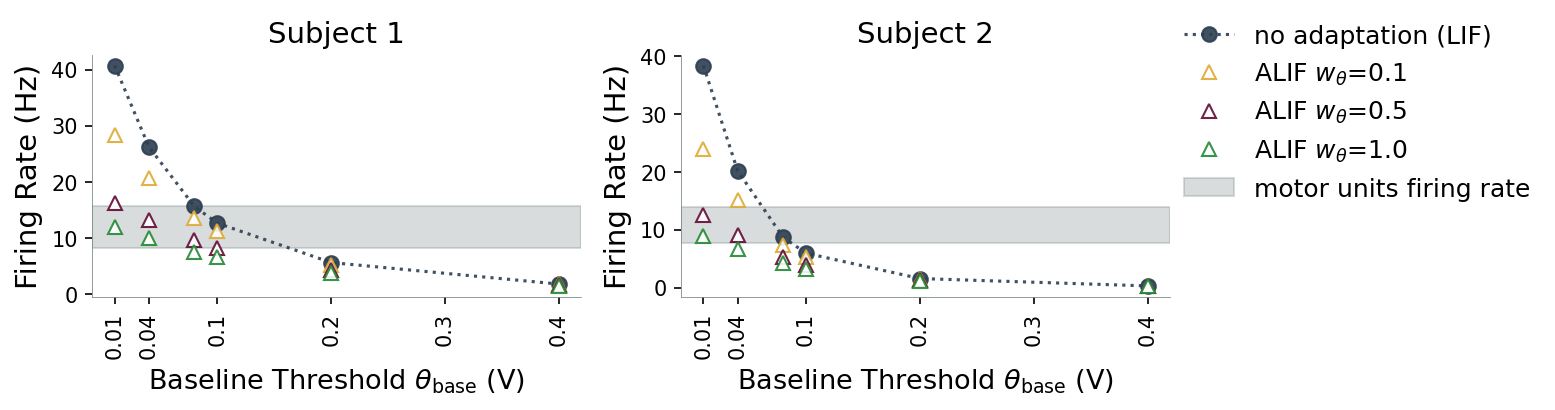

In [16]:
mark_mu_regions = True

if mark_mu_regions:
    fig_name=f"sensitivity_encoding_avg_fr_flexion_extension_mu_regions.pdf"
else:
    fig_name=f"sensitivity_encoding_avg_fr_flexion_extension.pdf"

plot_firing_rate_vs_threshold(enc_spikes_dfs,
                              sign_mvc_single=1, 
                               selected_taus=(0.1,),
                               across_directions=True,
                               fig_name=fig_name,
                               output_figures_dir=output_figures_dir,
                               mark_mu_regions=mark_mu_regions,
                               save_fig=True,
                               source_data_path=os.path.join(project_dir, source_data_main_file),
                               sheet_name='Fig9a_fr_thr')

# RMSE - threshold curves

In [20]:
def plot_rmse_threshold_curves(metrics_df, sign_mvc_single=1, n_channels=120, 
                   selected_taus=(0.1,),
                   selected_torch_seed=90,
                   plot_baseline=False,
                   baseline_thresholds=None,
                   save_fig=False, output_figures_dir=None, 
                   fig_name="rmse_plot.png",
                   source_data_path: str = None,
                   sheet_name: str = 'Fig_rmse_per_finger'):
    direction_map = {1: "Flexion", -1: "Extension"}

    n_tasks = metrics_df[FING_ID_COL].nunique()
    seeds = metrics_df[TORCH_SEED_COL].unique()
    if selected_torch_seed is not None:
        print(f"Selecting torch seed: {selected_torch_seed} from available seeds: {seeds}")
        metrics_df = metrics_df[metrics_df[TORCH_SEED_COL]==selected_torch_seed]
    selected_taus = tuple(np.atleast_1d(selected_taus).astype(float))
    
    finger_id_to_name = {v: k for k, v in data_config.finger_label_map.items()}
    
    threshold_scales = np.sort(metrics_df[ENC_ALIF_SCALE_COL].unique())
    n_scales = len(threshold_scales)
    alpha = 0.9 if n_scales > 1 else 1.0
    
    fig = plt.figure(figsize=(12, 3))
    gs = gridspec.GridSpec(nrows=1, ncols=n_tasks)
    
    colors = [COLORS["midnight_blue"], COLORS["mustard"], COLORS["burgundy"], COLORS["forest_green"]][:n_scales]
    tau_styles = ["o", "^", "--s", "-.d", ":v", "--<", "-.>"]

    save_frames = []

    for task_i in range(1, n_tasks + 1):
        ax = fig.add_subplot(gs[0, task_i - 1])
        rmse_subset = metrics_df[(metrics_df[FING_ID_COL] == task_i) & 
                                  (metrics_df[SIGN_MVC_COL] == sign_mvc_single) & 
                                  (metrics_df[MODE_COL] == "inference") &
                                  (metrics_df[USE_ALIF_COL]==True)]
        
        rmse_baseline = metrics_df[(metrics_df[FING_ID_COL] == task_i) & 
                                  (metrics_df[SIGN_MVC_COL] == sign_mvc_single) & 
                                  (metrics_df[MODE_COL] == "inference") &
                                  (metrics_df[USE_ALIF_COL]==False) &
                                  (metrics_df[ENC_SPK_THRESH1_COL].isin(baseline_thresholds)) &
                                  (metrics_df[ENC_SPK_THRESH2_COL].isin(baseline_thresholds)) &
                                  (metrics_df[ENC_SPK_THRESH3_COL].isin(baseline_thresholds))]
        if plot_baseline and not rmse_baseline.empty:
            mean_rmse_baseline = rmse_baseline.groupby(ENC_SPK_THRESH1_COL)[RMSE_TEST].mean()
            ax.axhline(y=mean_rmse_baseline.mean(), color=COLORS['pumpkin'], linestyle='dotted',
                      linewidth=1.5, alpha=0.7, label='Baseline (non-ALIF)')
            ax.axvline(x=mean_rmse_baseline.idxmin(), color=COLORS['pumpkin'], linestyle='dotted',
                      linewidth=1.5, alpha=0.7)
        
        if rmse_subset.empty:
            ax.set_axis_off()
            continue
            
        ax.set_title(f"{finger_id_to_name[task_i]}", fontsize=TITLE_FONTSIZE)

        save_cols = {}

        for scale_val in threshold_scales:
            df_scale = rmse_subset[rmse_subset[ENC_ALIF_SCALE_COL] == scale_val]
            for tau_i, tau_val in enumerate(selected_taus):
                df_tau = df_scale[df_scale[ENC_THRESHOLD_TAU_COL] == tau_val]
                if df_tau.empty:
                    continue
                    
                mean_rmse = df_tau.groupby(ENC_SPK_THRESH1_COL)[RMSE_TEST].mean()

                col_name = 'no_adaptation' if scale_val == 0 else f'w={scale_val}'
                save_cols[col_name] = mean_rmse

                color = colors[list(threshold_scales).index(scale_val)]
                base_style = tau_styles[tau_i % len(tau_styles)]
                markerstyle = "^" if (scale_val > 0 and tau_i == 0) else base_style
                linestyle = 'dotted' if (scale_val == 0) else 'None'
                face_color = color if scale_val == 0 else 'white'
                custom_label = rf"ALIF $w_\theta$ ={scale_val}" if scale_val > 0 else f"no adaptation (LIF)"

                ax.plot(mean_rmse.index, mean_rmse.values,
                       linestyle=linestyle,
                       marker=markerstyle,
                       color=color,
                       alpha=alpha,
                       markerfacecolor=face_color,
                       markeredgecolor=color,
                       markersize=7,
                       label=custom_label)
                
                min_thr = mean_rmse.idxmin()
                print(f"Lowest RMSE task {task_i} scale {scale_val} tau {tau_val}: {mean_rmse.min():.3f} at thr {min_thr:.3f}")

        if source_data_path is not None and save_cols:
            finger_df = pd.DataFrame(save_cols)
            finger_df.index.name = 'baseline_threshold'
            finger_df = finger_df.reset_index()
            finger_df.insert(0, 'finger', finger_id_to_name[task_i])
            save_frames.append(finger_df)

        if task_i == 1:
            ax.set_ylabel(RMSE_LABEL, fontsize=LABEL_FONTSIZE + 2)
        ax.set_xlabel(r"Threshold ($\theta_{\mathrm{base}}$)", fontsize=LABEL_FONTSIZE + 1)
        ax.set_xticks([0.01, 0.04, 0.10, 0.2, 0.3, 0.4, 0.5])
        ax.set_xticklabels([0.01, 0.04, 0.10, 0.2, 0.3, 0.4, 0.5], rotation=90, fontsize=8)
        ax.set_ylim([0, 8.5])
        sns.despine(ax=ax)
        if task_i == n_tasks:
            ax.legend(fontsize=LABEL_FONTSIZE, frameon=False, ncol=1, bbox_to_anchor=(0.88, 1))

    fig.tight_layout()
    
    if save_fig:
        if output_figures_dir is None:
            raise ValueError("output_figures_dir must be provided if save_fig is True.")
        out_path = os.path.join(output_figures_dir, fig_name)
        fig.savefig(out_path, dpi=300, bbox_inches="tight")

        if source_data_path is not None and save_frames:
            separator = pd.DataFrame([[''] * len(save_frames[0].columns)], columns=save_frames[0].columns)
            frames_with_sep = []
            for i, df in enumerate(save_frames):
                frames_with_sep.append(df)
                if i < len(save_frames) - 1:
                    frames_with_sep.append(separator)
            combined = pd.concat(frames_with_sep, ignore_index=True)
            mode = 'a' if os.path.exists(source_data_path) else 'w'
            kwargs = {'if_sheet_exists': 'replace'} if mode == 'a' else {}
            with pd.ExcelWriter(source_data_path, mode=mode, **kwargs) as writer:
                combined.to_excel(writer, sheet_name=sheet_name, index=False)
                worksheet = writer.sheets[sheet_name]
                for col in worksheet.columns:
                    max_len = max(len(str(cell.value)) if cell.value else 0 for cell in col)
                    worksheet.column_dimensions[col[0].column_letter].width = max_len + 2

    return None


In [ ]:
subjects = ['S1', 'S2']
metrics_df = cr.load_and_parse_snn_data_to_df(dt=0.01, subject_list=subjects,
                                            data_type='metrics_df_cv_snn',
                                            network_topology=f'{ENC_SHALLOW_LEAKY}',
                                            results_dir=results_dir,
                                            config=config)


Selecting torch seed: 90 from available seeds: [90  8 64 28 73 89  9 29 15  0]
Lowest RMSE task 1 scale 0.0 tau 0.1: 2.339 at thr 0.080
Lowest RMSE task 1 scale 0.1 tau 0.1: 2.374 at thr 0.100
Lowest RMSE task 1 scale 0.5 tau 0.1: 2.497 at thr 0.100
Lowest RMSE task 1 scale 1.0 tau 0.1: 2.659 at thr 0.100
Lowest RMSE task 2 scale 0.0 tau 0.1: 3.161 at thr 0.100
Lowest RMSE task 2 scale 0.1 tau 0.1: 3.251 at thr 0.100
Lowest RMSE task 2 scale 0.5 tau 0.1: 3.558 at thr 0.100
Lowest RMSE task 2 scale 1.0 tau 0.1: 3.811 at thr 0.100
Lowest RMSE task 3 scale 0.0 tau 0.1: 1.601 at thr 0.100
Lowest RMSE task 3 scale 0.1 tau 0.1: 1.612 at thr 0.100
Lowest RMSE task 3 scale 0.5 tau 0.1: 1.580 at thr 0.100
Lowest RMSE task 3 scale 1.0 tau 0.1: 1.560 at thr 0.100
Lowest RMSE task 4 scale 0.0 tau 0.1: 2.056 at thr 0.100
Lowest RMSE task 4 scale 0.1 tau 0.1: 2.146 at thr 0.100
Lowest RMSE task 4 scale 0.5 tau 0.1: 2.196 at thr 0.200
Lowest RMSE task 4 scale 1.0 tau 0.1: 2.301 at thr 0.200
Lowest RM

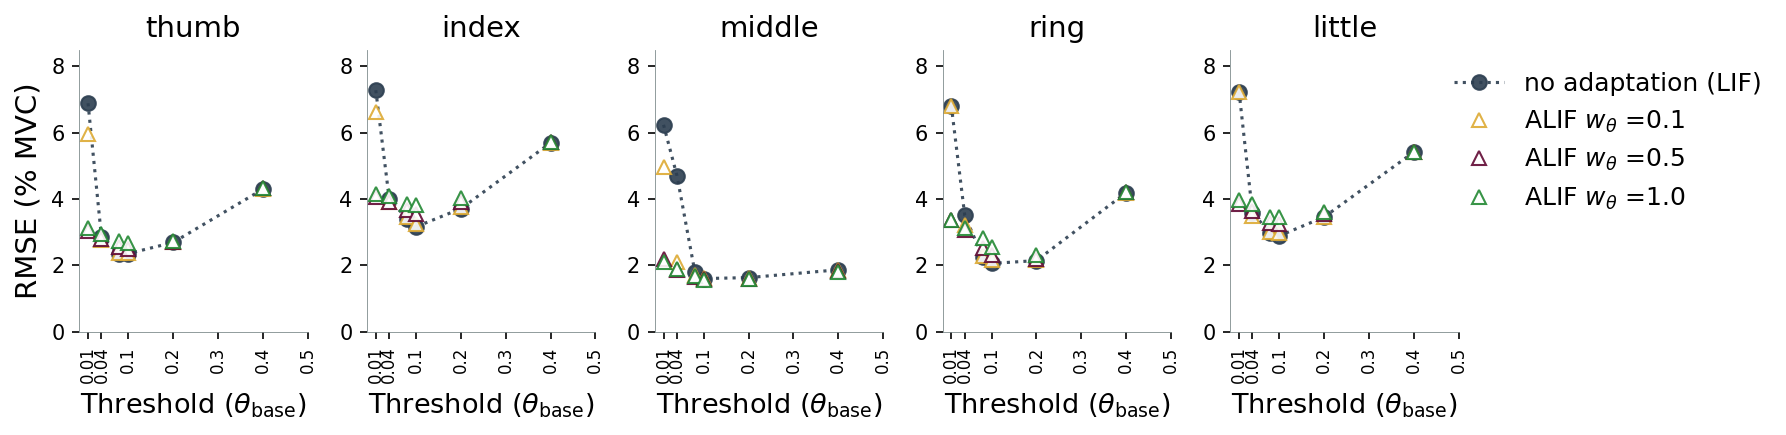

In [24]:
selected_subject = 'S2'
sign_mvc_single = -1 # 1: flexion | -1: extension

fig_name = f"{selected_subject}_sensitivity_encoding_rmse_mvc_15_sign_{sign_mvc_single}_bothreps.pdf"
plot_rmse_threshold_curves(metrics_df[(metrics_df[SUBJECT_COL]==selected_subject)], 
               sign_mvc_single=sign_mvc_single, 
               n_channels=120, 
               selected_taus=(0.1,), 
                plot_baseline=False,
                baseline_thresholds=[0.1],
               save_fig=True,
               output_figures_dir=output_figures_dir,
               fig_name=fig_name,
               source_data_path=os.path.join(project_dir, source_data_supp_file),
                sheet_name='SFig12b_rmse_thr_direction')

In [27]:
def plot_rmse_averaged_threshold_curves(metrics_df, sign_mvc_single=1,
                       selected_taus=(0.1,),
                       selected_torch_seed=90,
                       plot_baseline=False,
                       baseline_thresholds=None,
                       across_directions=False,
                       save_fig=False, output_figures_dir=None, 
                       fig_name="rmse_averaged_plot.png",
                       source_data_path: str = None,
                       sheet_name: str = 'Fig_rmse_averaged'):
    direction_map = {1: "Flexion", -1: "Extension"}
    
    seeds = metrics_df[TORCH_SEED_COL].unique()
    if selected_torch_seed is not None:
        print(f"Selecting torch seed: {selected_torch_seed} from available seeds: {seeds}")
        metrics_df = metrics_df[metrics_df[TORCH_SEED_COL] == selected_torch_seed]
    selected_taus = tuple(np.atleast_1d(selected_taus).astype(float))
    
    threshold_scales = np.sort(metrics_df[ENC_ALIF_SCALE_COL].unique())
    n_scales = len(threshold_scales)
    alpha = 0.9 if n_scales > 1 else 1.0
    
    fig = plt.figure(figsize=(8,2.8)) 
    gs = gridspec.GridSpec(1, 2)
    
    colors = [COLORS["midnight_blue"], COLORS["mustard"], COLORS["burgundy"], COLORS["forest_green"]][:n_scales]
    tau_styles = ["o", "^", "--s", "-.d", ":v", "--<", "-.>"]

    save_frames = []

    for col, subject in enumerate(['S1', 'S2']):
        ax = fig.add_subplot(gs[0, col])
        ax.set_title(f"Subject {subject.split('S')[-1]}", fontsize=TITLE_FONTSIZE)

        subject_metrics_df = metrics_df[metrics_df[SUBJECT_COL]==subject]

        rmse_subset = subject_metrics_df[(subject_metrics_df[MODE_COL] == "inference") &
                                         (subject_metrics_df[USE_ALIF_COL] == True)]

        rmse_baseline = subject_metrics_df[(subject_metrics_df[MODE_COL] == "inference") &
                                (subject_metrics_df[USE_ALIF_COL] == False) &
                                (subject_metrics_df[ENC_SPK_THRESH1_COL].isin(baseline_thresholds if baseline_thresholds else [])) &
                                (subject_metrics_df[ENC_SPK_THRESH2_COL].isin(baseline_thresholds if baseline_thresholds else [])) &
                                (subject_metrics_df[ENC_SPK_THRESH3_COL].isin(baseline_thresholds if baseline_thresholds else []))]
        if not across_directions:
            rmse_subset = rmse_subset[rmse_subset[SIGN_MVC_COL] == sign_mvc_single]
            rmse_baseline = rmse_baseline[rmse_baseline[SIGN_MVC_COL] == sign_mvc_single]
        
        if plot_baseline and not rmse_baseline.empty:
            mean_rmse_baseline = rmse_baseline.groupby(ENC_SPK_THRESH1_COL)[RMSE_TEST].mean()
            ax.axhline(y=mean_rmse_baseline.mean(), color=COLORS['pumpkin'], linestyle='dotted',
                    linewidth=1.5, alpha=0.7, label='Baseline (non-ALIF)')
            ax.axvline(x=mean_rmse_baseline.idxmin(), color=COLORS['pumpkin'], linestyle='dotted',
                    linewidth=1.5, alpha=0.7)
        
        if rmse_subset.empty:
            print("No ALIF data found for the specified parameters.")
            return None

        save_cols = {}

        for scale_val in threshold_scales:
            df_scale = rmse_subset[rmse_subset[ENC_ALIF_SCALE_COL] == scale_val]
            for tau_i, tau_val in enumerate(selected_taus):
                df_tau = df_scale[df_scale[ENC_THRESHOLD_TAU_COL] == tau_val]
                if df_tau.empty:
                    continue
                
                grouped = df_tau.groupby(ENC_SPK_THRESH1_COL)[RMSE_TEST]
                mean_rmse = grouped.mean()
                std_rmse = grouped.std()

                col_name = 'no_adaptation' if scale_val == 0 else f'w={scale_val}'
                save_cols[col_name] = mean_rmse
                
                color = colors[list(threshold_scales).index(scale_val)]
                base_style = tau_styles[tau_i % len(tau_styles)]
                markerstyle = "^" if (scale_val > 0 and tau_i == 0) else base_style
                linestyle = 'dotted' if (scale_val == 0) else 'None'
                face_color = color if scale_val == 0 else 'white'
                custom_label = rf"ALIF $w_\theta$ ={scale_val}" if scale_val > 0 else f"no adaptation (LIF)"

                ax.plot(mean_rmse.index, mean_rmse.values,
                        linestyle=linestyle,
                        marker=markerstyle,
                        color=color,
                        alpha=alpha,
                        markerfacecolor=face_color,
                        markeredgecolor=color,
                        markersize=7,
                        label=custom_label)
                handles, labels = ax.get_legend_handles_labels()
                min_thr = mean_rmse.idxmin()
                print(f"Lowest avg RMSE scale {scale_val} tau {tau_val}: {mean_rmse.min():.3f} +/- {std_rmse[min_thr]:.3f} at thr {min_thr:.3f}")

        if source_data_path is not None and save_cols:
            subject_df = pd.DataFrame(save_cols)
            subject_df.index.name = 'baseline_threshold'
            subject_df = subject_df.reset_index()
            subject_df.insert(0, 'subject', subject)
            save_frames.append(subject_df)

        ax.set_ylabel(RMSE_LABEL, fontsize=LABEL_FONTSIZE + 2)
        ax.set_xlabel(r"Baseline Threshold $\theta_{\mathrm{base}}$ (V)", fontsize=LABEL_FONTSIZE + 1)
        ax.set_xticks([0.01, 0.04, 0.10, 0.2, 0.3, 0.4])
        ax.set_xticklabels([0.01, 0.04, 0.10, 0.2, 0.3, 0.4], rotation=90, fontsize=10)
        sns.despine(ax=ax)

    fig.legend(handles=handles, fontsize=LABEL_FONTSIZE, frameon=False, ncol=1,
               bbox_to_anchor=(1.3, 0.99))
    fig.tight_layout()
    
    if save_fig:
        if output_figures_dir is None:
            raise ValueError("output_figures_dir must be provided if save_fig is True.")
        out_path = os.path.join(output_figures_dir, fig_name)
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to: {out_path}")

        if source_data_path is not None and save_frames:
            separator = pd.DataFrame([[''] * len(save_frames[0].columns)], columns=save_frames[0].columns)
            frames_with_sep = []
            for i, df in enumerate(save_frames):
                frames_with_sep.append(df)
                if i < len(save_frames) - 1:
                    frames_with_sep.append(separator)
            combined = pd.concat(frames_with_sep, ignore_index=True)
            io.save_to_source_data(source_data_path, combined, sheet_name=sheet_name)


    return None


Selecting torch seed: 90 from available seeds: [ 8 90 64 28 73 89  9 29 15  0]
Lowest avg RMSE scale 0.0 tau 0.1: 2.748 +/- 1.814 at thr 0.200
Lowest avg RMSE scale 0.1 tau 0.1: 2.674 +/- 1.480 at thr 0.100
Lowest avg RMSE scale 0.5 tau 0.1: 2.692 +/- 1.480 at thr 0.100
Lowest avg RMSE scale 1.0 tau 0.1: 2.742 +/- 1.466 at thr 0.100
Lowest avg RMSE scale 0.0 tau 0.1: 2.843 +/- 1.158 at thr 0.100
Lowest avg RMSE scale 0.1 tau 0.1: 2.897 +/- 1.169 at thr 0.100
Lowest avg RMSE scale 0.5 tau 0.1: 3.033 +/- 1.217 at thr 0.100
Lowest avg RMSE scale 1.0 tau 0.1: 3.148 +/- 1.241 at thr 0.100
Figure saved to: /Volumes/big usb drive/snn-fingerforce-decoding-results/results/figures/sensitivity_encoding_avg_rmse_flexion_extension.pdf
Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataMain.xlsx in sheet 'Fig9b_rmse_thr'.


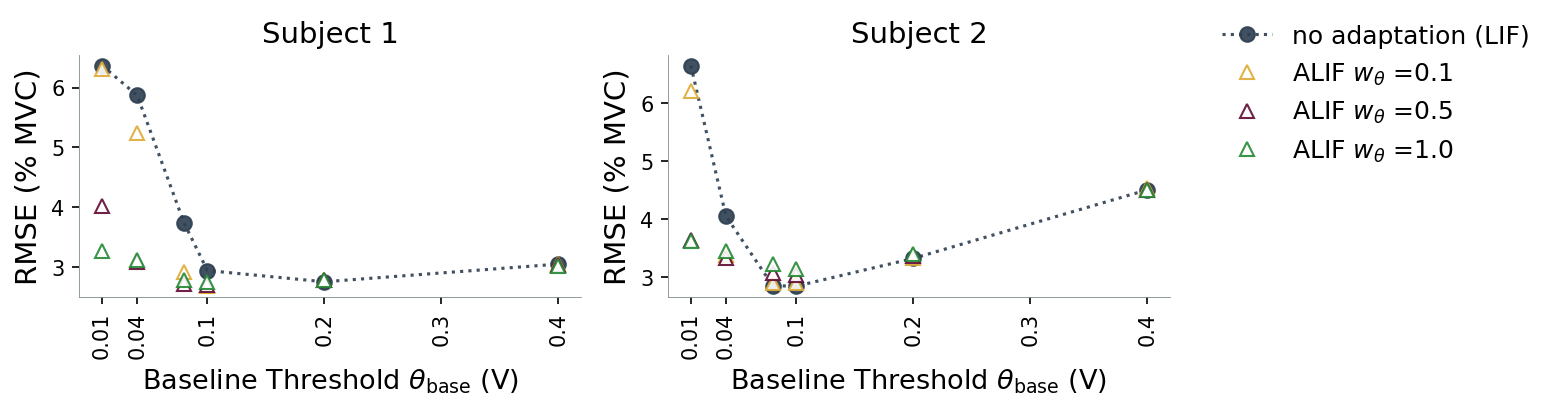

In [28]:
# Plot average RMSE across all fingers for flexion
fig_name=f"sensitivity_encoding_avg_rmse_flexion_extension.pdf"
plot_rmse_averaged_threshold_curves(metrics_df, 
                   sign_mvc_single=1, 
                   selected_taus=(0.1,),
                   selected_torch_seed=90,
                   across_directions=True,
                   plot_baseline=False,
                   fig_name=fig_name,
                    output_figures_dir=output_figures_dir,
                   save_fig=True,
                   source_data_path=os.path.join(project_dir, source_data_main_file),
                    sheet_name='Fig9b_rmse_thr')

# Save mean event rates across channels

In [29]:
def compute_mean_firing_rates(enc_spikes_dfs, group_cols, n_channels=120,
                              output_dir:str=None,
                              save_file:bool=False):

    """Compute mean firing rate per channel and across channels for each subject.

    Parameters
    ----------
    enc_spikes_dfs : dict
        Dictionary of encoded spikes DataFrames keyed by subject (e.g. 'S1', 'S2').
    group_cols : list
        Columns to group by.
    n_channels : int
        Number of channels.
    save_file : bool
        If True, save the resulting DataFrame to the specified output directory.

    Returns
    -------
    pd.DataFrame
        Combined DataFrame with per-channel means, mean_across_channels, and std_across_channels.
    """
    channel_cols = np.arange(n_channels)
    all_firing_rates = []

    for subject in enc_spikes_dfs:
        for sign_mvc in enc_spikes_dfs[subject][SIGN_MVC_COL].unique():
            
            subset = enc_spikes_dfs[subject][enc_spikes_dfs[subject][SIGN_MVC_COL] == sign_mvc]
            grouped_subset = subset.groupby(group_cols)[channel_cols].mean()
            
            mean_across_channels = grouped_subset.mean(axis=1)
            std_across_channels = grouped_subset.std(axis=1)
            grouped_subset['mean_across_channels'] = mean_across_channels
            grouped_subset['std_across_channels'] = std_across_channels
            grouped_subset[SIGN_MVC_COL] = sign_mvc
            grouped_subset[SUBJECT_COL] = subject
            all_firing_rates.append(grouped_subset.reset_index())
    firing_rates_df = pd.concat(all_firing_rates, ignore_index=True)
    channel_rename = {i: f'channel_{i}' for i in channel_cols}
    firing_rates_df.rename(columns=channel_rename, inplace=True)

    if save_file and output_dir is not None:
        save_csv = os.path.join(output_dir, "alif_mean_event_rates_channel_and_across_channels.csv")
        firing_rates_df.to_csv(save_csv, index=False)
        print(f'Saved to {save_csv}')
    return firing_rates_df

In [30]:
group_cols = [ENC_ALIF_SCALE_COL, ENC_THRESHOLD_TAU_COL, ENC_SPK_THRESH1_COL]

firing_rates_df =compute_mean_firing_rates(enc_spikes_dfs, group_cols, n_channels=120,
                              output_dir=output_figures_dir,
                              save_file=False)
firing_rates_df

,enc_alif_scale,enc_threshold_tau,enc_spk_threshold1,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,...,channel_114,channel_115,channel_116,channel_117,channel_118,channel_119,mean_across_channels,std_across_channels,sign_mvc,subject
0,0.0,0.1,0.01,39.410000,40.843333,39.403333,41.453333,39.673333,39.853333,39.840000,...,39.380000,40.433333,39.366667,39.360000,40.850000,39.620000,40.327917,1.800051,1,S1
1,0.0,0.1,0.04,21.866667,26.143333,21.780000,26.846667,22.656667,23.176667,23.186667,...,22.706667,24.906667,23.166667,22.996667,26.236667,24.196667,24.979750,4.386406,1,S1
2,0.0,0.1,0.08,10.230000,13.923333,10.540000,14.086667,11.600000,11.180000,11.386667,...,13.156667,15.080000,14.790000,14.736667,15.956667,15.746667,14.020250,4.853226,1,S1
3,0.0,0.1,0.10,7.913333,10.320000,8.173333,10.116667,9.493333,8.680000,9.083333,...,11.006667,12.766667,12.863333,12.783333,13.536667,13.683333,11.148194,4.485940,1,S1
4,0.0,0.1,0.20,3.126667,3.883333,3.190000,3.363333,4.660000,3.540000,4.023333,...,6.140000,7.166667,7.113333,7.460000,7.933333,7.846667,4.696750,2.749092,1,S1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,1.0,0.1,0.04,11.466667,11.506667,10.926667,11.466667,9.853333,10.776667,10.253333,...,4.543333,5.406667,4.340000,4.656667,5.083333,4.373333,7.324111,2.680361,-1,S2
92,1.0,0.1,0.08,9.123333,9.213333,8.620000,9.206667,7.390000,8.423333,7.813333,...,1.520000,2.320000,1.413333,1.640000,1.940000,1.436667,4.827056,2.636416,-1,S2
93,1.0,0.1,0.10,8.163333,8.220000,7.600000,8.193333,6.233333,7.360000,6.696667,...,0.600000,1.160000,0.566667,0.676667,0.926667,0.590000,3.859222,2.476523,-1,S2
94,1.0,0.1,0.20,5.333333,5.383333,4.636667,5.430000,2.910000,4.336667,3.506667,...,0.003333,0.006667,0.000000,0.010000,0.010000,0.010000,1.522667,1.315056,-1,S2


# Plot firing rate heatmap

In [45]:
from matplotlib.colors import LinearSegmentedColormap

def plot_firing_rate_heatmap(enc_spikes_dfs, subject='S1',
                              sign_mvc_single=1,
                              alif_scale=0.1,
                              threshold=0.1,
                              tau=0.1,
                              rep_id=2,
                              n_channels=120,
                              save_fig=False,
                              output_figures_dir=None,
                              fig_name='firing_rate_heatmap.png',
                              source_data_path=None,
                              sheet_name='Fig_firing_rate_heatmap'):
    """
    Plot mean firing rate heatmap: rows = fingers, columns = HD-iEMG channels.
    Filters to a specific subject, direction, ALIF scale, threshold, tau, and rep.
    """
    chan_cols = np.arange(n_channels)
    # finger order top-to-bottom matching figure: little -> thumb
    finger_order = ['little', 'ring', 'middle', 'index', 'thumb']

    df = enc_spikes_dfs[subject]

    subset = df[(df[ENC_ALIF_SCALE_COL] == alif_scale) &
                (df[ENC_SPK_THRESH1_COL] == threshold) &
                (df[ENC_THRESHOLD_TAU_COL] == tau) &
                (df[SIGN_MVC_COL] == sign_mvc_single) &
                (df[REP_ID] == rep_id)]

    if subset.empty:
        print("No data found for the specified parameters.")
        return None
    
    burgundy_cmap = LinearSegmentedColormap.from_list('burgundy', ['white', COLORS['burgundy']])
    

    # Build matrix: rows = fingers (top-to-bottom), cols = channels
    heatmap_matrix = np.full((len(finger_order), n_channels), np.nan)
    for i, fname in enumerate(finger_order):
        row = subset[subset[FING_NAME_COL] == fname]
        if not row.empty:
            heatmap_matrix[i] = row[chan_cols].values.mean(axis=0)

    fig, ax = plt.subplots(figsize=(10, 3))
    hm = sns.heatmap(heatmap_matrix, ax=ax,
                     cmap=burgundy_cmap,
                     yticklabels=finger_order,
                     cbar_kws={'label': 'Firing Rate (Hz)',
                               'fraction': 0.02, 'pad': 0.02,
                               'shrink':0.8},
                     vmin=0)
    ax.set_xlabel('Encoded HD-iEMG Channel', fontsize=LABEL_FONTSIZE)
    ax.set_ylabel('')
    ax.set_xticks(np.arange(0, n_channels , 20))
    ax.set_xticklabels(np.arange(0, n_channels, 20),
                       fontsize=LABEL_FONTSIZE, rotation=0)
    ax.set_yticklabels(finger_order, rotation=0, fontsize=LABEL_FONTSIZE)

    fig.tight_layout()

    if save_fig:
        if output_figures_dir is None:
            raise ValueError("output_figures_dir must be provided if save_fig is True.")
        fig_name = f"{subject}_alif_scale_{alif_scale}_tau_{tau}_threshold_{threshold}_rep_{rep_id}_fr.pdf"
        out_path = os.path.join(output_figures_dir, fig_name)
        fig.savefig(out_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {out_path}")

        if source_data_path is not None:
            save_df = pd.DataFrame(heatmap_matrix.T, columns=finger_order)
            save_df.insert(0, 'channel', chan_cols)
            io.save_to_source_data(source_data_path, save_df, sheet_name=sheet_name)


    return fig, ax


Figure saved to: /Volumes/big usb drive/snn-fingerforce-decoding-results/results/figures/S1_alif_scale_0.1_tau_0.1_threshold_0.1_rep_2_fr.pdf
Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataMain.xlsx in sheet 'Fig8c_firingrates'.


(<Figure size 1500x450 with 2 Axes>, <Axes: xlabel='Encoded HD-iEMG Channel'>)

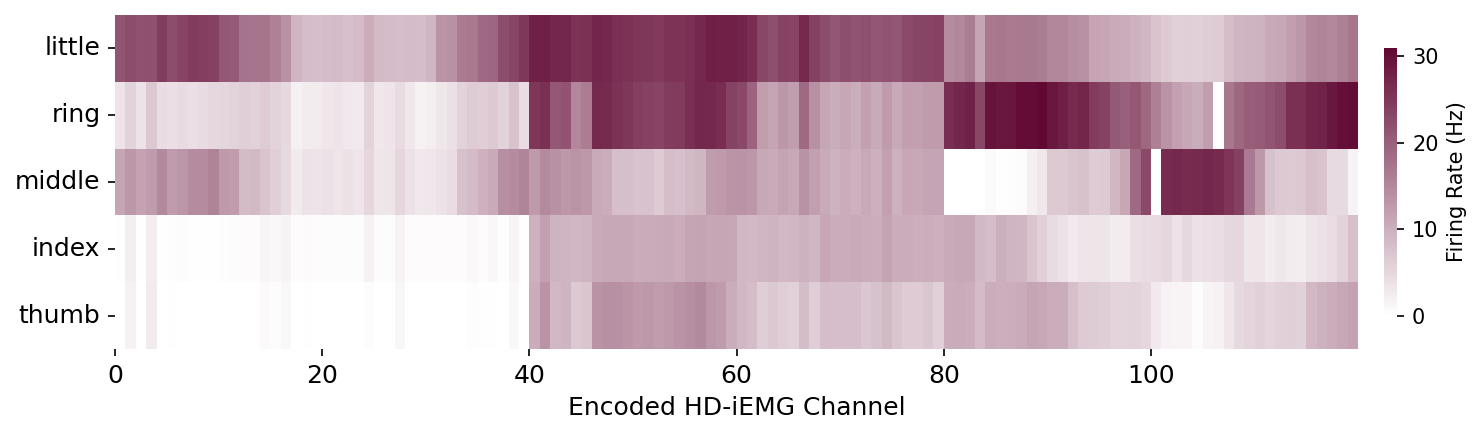

In [47]:
# plot firing rate heatmap for selected subject, sign_mvc, weight, threhold
# w=0.1, threshold0.1, rep2, subject S1, flexion
subject = 'S1'
sign_mvc_single = 1
alif_scale = 0.1
threshold = 0.1

rep_id=2



plot_firing_rate_heatmap(enc_spikes_dfs,
                         subject=subject,
                         sign_mvc_single=sign_mvc_single,
                          alif_scale=alif_scale,
                          threshold=threshold, tau=0.1,
                          rep_id=rep_id,
                          save_fig=True,
                          output_figures_dir=output_figures_dir,
                          source_data_path=os.path.join(project_dir, source_data_main_file),
                          sheet_name='Fig8c_firingrates')
